# 📊 Analyse Comparative — Toutes les Phases

Objectif : compiler tous les résultats en un tableau unifié, visualiser les trade-offs et identifier les configurations optimales par cas d'usage.

In [1]:
# Cellule 1: Setup
import os, json, pickle, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) != 'experiments':
    if (Path(os.getcwd()) / 'experiments').exists():
        os.chdir(Path(os.getcwd()) / 'experiments')
sys.path.insert(0, str(Path(os.getcwd()).parent / 'utils'))
from fairness_metrics import compute_fairness_metrics, bootstrap_ci

R  = Path('../results')
R5 = R / 'phase5'
FIGS = R5 / 'figures'
R5.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
print(f'📁 {os.getcwd()}')


📁 /Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/experiments


## 📥 Chargement de Tous les Résultats

In [9]:
# Cellule 2: Charger et consolider les CSV de toutes les phases
def safe_read(path, **kw):
    p = Path(path)
    return pd.read_csv(p, **kw) if p.exists() else pd.DataFrame()

# ── Phase 2 ────────────────────────────────────────────
emb_df  = safe_read(R/'phase2/embedding_comparison_results.csv', index_col=0)
clf_df  = safe_read(R/'phase2/classifier_comparison_results.csv', index_col=0)
rf_df   = safe_read(R/'phase2/rf_hyperparameter_results.csv')

# ── Phase 4 ────────────────────────────────────────────
pre_df  = safe_read(R/'phase4/preprocessing_results.csv',  index_col=0)
post_df = safe_read(R/'phase4/postprocessing_results.csv', index_col=0)
inpr_df = safe_read(R/'phase4/inprocessing_results.csv')

# ── Phase 3 (CI bootstrap) ─────────────────────────────
ci_df   = safe_read(R/'phase3/bootstrap_confidence_intervals.csv')
viol_df = safe_read(R/'phase3/fairness_violations_report.csv')

print('📦 Fichiers chargés:')
for name, df in [('Embeddings (P2)', emb_df), ('Classifiers (P2)', clf_df),
                  ('Pre-processing (P4)', pre_df), ('Post-processing (P4)', post_df),
                  ('In-processing (P4)', inpr_df)]:
    status = f'{len(df)} configs' if not df.empty else '⚠️  absent (notebook pas encore exécuté)'
    print(f'  {name}: {status}')


📦 Fichiers chargés:
  Embeddings (P2): 5 configs
  Classifiers (P2): 4 configs
  Pre-processing (P4): 7 configs
  Post-processing (P4): 5 configs
  In-processing (P4): 10 configs


In [10]:
# Cellule 3: Construire le tableau unifié
COLS = ['accuracy', 'delta_dp', 'delta_eo', 'delta_eqodds']
frames = []

def add_frame(df, phase, category):
    if df.empty: return
    sub = df[[c for c in COLS if c in df.columns]].copy()
    sub.index.name = 'config'
    sub = sub.reset_index()
    sub.columns = ['config'] + [c for c in COLS if c in df.columns]
    sub['phase']    = phase
    sub['category'] = category
    frames.append(sub)

add_frame(emb_df,  'Phase 2', 'Embedding')
add_frame(clf_df,  'Phase 2', 'Classifier')
add_frame(pre_df,  'Phase 4', 'Pre-processing')
add_frame(post_df, 'Phase 4', 'Post-processing')

if not inpr_df.empty and 'label' in inpr_df.columns:
    inpr_sub = inpr_df.set_index('label')[[c for c in COLS if c in inpr_df.columns]].copy()
    add_frame(inpr_sub, 'Phase 4', 'In-processing')

if frames:
    master = pd.concat(frames, ignore_index=True)
    for c in COLS:
        if c not in master.columns: master[c] = np.nan
    master['mean_gap']  = master[['delta_dp','delta_eo','delta_eqodds']].mean(axis=1)
    master['composite'] = master['accuracy'] - master['mean_gap']
    print(f'✅ Tableau maître: {len(master)} configurations')
    print(master.groupby('category')[['accuracy','mean_gap','composite']].mean().round(4).to_string())
else:
    print('⚠️  Aucun CSV trouvé — lancez les notebooks des phases 2-4 avant celui-ci')
    master = pd.DataFrame(columns=['config','phase','category','accuracy','delta_dp','delta_eo','delta_eqodds','mean_gap','composite'])


✅ Tableau maître: 31 configurations
                 accuracy  mean_gap  composite
category                                      
Classifier         0.9525    0.1065     0.8460
Embedding          0.8548    0.1815     0.6733
In-processing      0.9707    0.0747     0.8960
Post-processing    0.8954    0.1656     0.7298
Pre-processing     0.9040    0.1481     0.7559


## 🎯 Configurations Optimales par Cas d'Usage

In [11]:
# Cellule 4: Top configs par cas d'usage
if not master.empty:
    use_cases = {
        '🏥 Déploiement clinique (équilibre)':     master.nlargest(1, 'composite'),
        '🎯 Précision maximale (recherche)':        master.nlargest(1, 'accuracy'),
        '⚖️  Fairness maximale (audit)':            master.nsmallest(1, 'mean_gap'),
        '🔬 Meilleur ∆EO (égalité opportunité)':   master.nsmallest(1, 'delta_eo'),
        '📊 Meilleur ∆DP (parité démographique)':  master.nsmallest(1, 'delta_dp'),
    }

    print('🎯 CONFIGURATIONS OPTIMALES PAR CAS D USAGE')
    print('='*60)
    for use_case, row in use_cases.items():
        if row.empty: continue
        r = row.iloc[0]
        print(f'\n{use_case}')
        print(f'  Config    : {r["config"]} ({r["category"]})')
        print(f'  Accuracy  : {r["accuracy"]:.4f}')
        print(f'  Mean gap  : {r["mean_gap"]:.4f}')
        print(f'  Composite : {r["composite"]:.4f}')


🎯 CONFIGURATIONS OPTIMALES PAR CAS D USAGE

🏥 Déploiement clinique (équilibre)
  Config    : λ=0.1 (eo) (In-processing)
  Accuracy  : 0.9750
  Mean gap  : 0.0709
  Composite : 0.9041

🎯 Précision maximale (recherche)
  Config    : λ=0.1 (eo) (In-processing)
  Accuracy  : 0.9750
  Mean gap  : 0.0709
  Composite : 0.9041

⚖️  Fairness maximale (audit)
  Config    : λ=1.0 (dp) (In-processing)
  Accuracy  : 0.9690
  Mean gap  : 0.0661
  Composite : 0.9029

🔬 Meilleur ∆EO (égalité opportunité)
  Config    : λ=1.0 (dp) (In-processing)
  Accuracy  : 0.9690
  Mean gap  : 0.0661
  Composite : 0.9029

📊 Meilleur ∆DP (parité démographique)
  Config    : Undersampling (Pre-processing)
  Accuracy  : 0.8780
  Mean gap  : 0.0930
  Composite : 0.7850


## 📡 Radar Plots

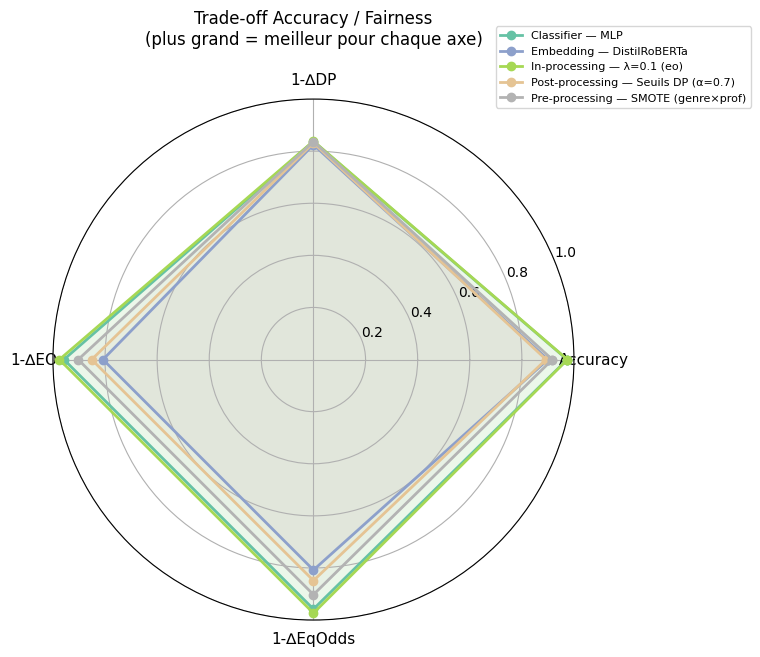

In [12]:
# Cellule 5: Radar plots — top config de chaque catégorie
if not master.empty:
    # Sélectionner la meilleure config par catégorie
    top_per_cat = master.loc[master.groupby('category')['composite'].idxmax()]

    metrics_radar = ['accuracy', 'delta_dp', 'delta_eo', 'delta_eqodds']
    labels = ['Accuracy', '1-∆DP', '1-∆EO', '1-∆EqOdds']
    N = len(metrics_radar)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors = plt.cm.Set2(np.linspace(0, 1, len(top_per_cat)))

    for (_, row), color in zip(top_per_cat.iterrows(), colors):
        values = [
            row['accuracy'],
            1 - row['delta_dp'],
            1 - row['delta_eo'],
            1 - row['delta_eqodds'],
        ]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, color=color,
                label=f"{row['category']} — {row['config']}"[:45])
        ax.fill(angles, values, alpha=0.08, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title('Trade-off Accuracy / Fairness\n(plus grand = meilleur pour chaque axe)', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGS/'radar_tradeoffs.png', dpi=150, bbox_inches='tight')
    plt.show()


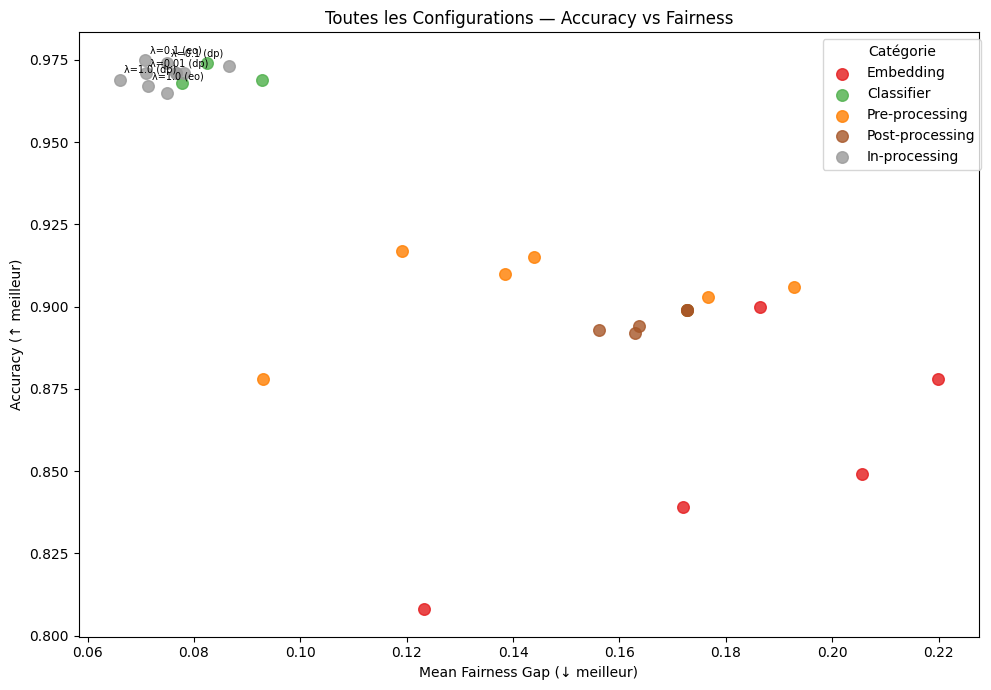

In [13]:
# Cellule 6: Scatter global accuracy vs fairness, coloré par catégorie
if not master.empty:
    fig, ax = plt.subplots(figsize=(10, 7))
    cats = master['category'].unique()
    palette = dict(zip(cats, plt.cm.Set1(np.linspace(0, 1, len(cats)))))

    for cat in cats:
        sub = master[master['category'] == cat]
        ax.scatter(sub['mean_gap'], sub['accuracy'], label=cat,
                   color=palette[cat], s=70, alpha=0.8, zorder=3)

    # Annoter les top 5
    for _, r in master.nlargest(5, 'composite').iterrows():
        ax.annotate(r['config'][:20], (r['mean_gap'], r['accuracy']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')

    ax.set_xlabel('Mean Fairness Gap (↓ meilleur)')
    ax.set_ylabel('Accuracy (↑ meilleur)')
    ax.set_title('Toutes les Configurations — Accuracy vs Fairness')
    ax.legend(title='Catégorie', bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.savefig(FIGS/'all_configs_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()


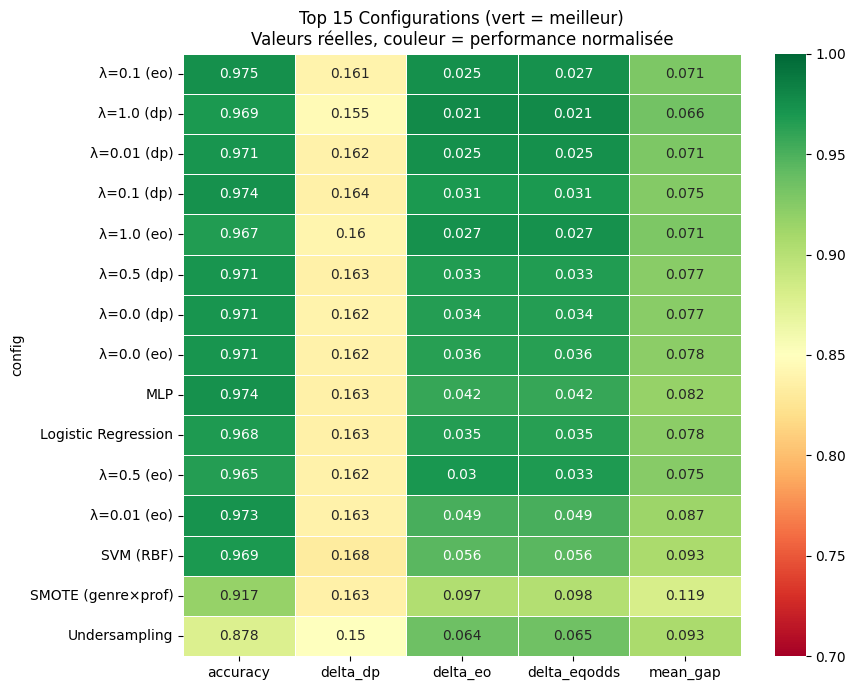

In [14]:
# Cellule 7: Heatmap des métriques par config (top 15 par composite)
if not master.empty:
    top15 = master.nlargest(15, 'composite').set_index('config')
    heat_data = top15[['accuracy','delta_dp','delta_eo','delta_eqodds','mean_gap']]

    # Normaliser : accuracy ↑ bon, gaps ↓ bon → inverser les gaps pour la heatmap
    norm = heat_data.copy()
    for c in ['delta_dp','delta_eo','delta_eqodds','mean_gap']:
        norm[c] = 1 - norm[c]

    plt.figure(figsize=(9, 7))
    sns.heatmap(norm, annot=heat_data.round(3), fmt='', cmap='RdYlGn',
                vmin=0.7, vmax=1.0, linewidths=0.5)
    plt.title('Top 15 Configurations (vert = meilleur)\n'
              'Valeurs réelles, couleur = performance normalisée')
    plt.tight_layout()
    plt.savefig(FIGS/'top15_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


In [15]:
# Cellule 8: Sauvegarder
if not master.empty:
    master.to_csv(R5/'master_results.csv', index=False)
    # JSON des configs optimales par use case
    optimal = {}
    for label, df_sub in [
        ('balanced',       master.nlargest(1, 'composite')),
        ('max_accuracy',   master.nlargest(1, 'accuracy')),
        ('max_fairness',   master.nsmallest(1, 'mean_gap')),
    ]:
        if not df_sub.empty:
            r = df_sub.iloc[0]
            optimal[label] = {'config': r['config'], 'category': r['category'],
                               'accuracy': round(r['accuracy'],4),
                               'mean_gap': round(r['mean_gap'],4),
                               'composite': round(r['composite'],4)}
    with open(R5/'optimal_configs.json', 'w') as f:
        json.dump(optimal, f, indent=2)
    print('💾 master_results.csv')
    print('💾 optimal_configs.json')
print('🎉 Notebook 12 terminé!')


💾 master_results.csv
💾 optimal_configs.json
🎉 Notebook 12 terminé!
